In [ ]:
# @title
!pip -q install nltk

In [ ]:
# @title
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm

In [ ]:
# @title
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# @title
from google.colab import files

uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

print("Dataset file:", DATA_PATH)

Saving vast_english_french.txt to vast_english_french (1).txt
Dataset file: vast_english_french (1).txt


In [ ]:
# @title
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?¿¡,;:])", r" \1 ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9.!?¿¡,;:'’\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def read_pairs(path):
    pairs = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if "\t" in line:
                parts = line.split("\t")
            elif "|||" in line:
                parts = line.split("|||")
            elif "," in line:
                parts = line.split(",", 1)
            else:
                continue

            if len(parts) >= 2:
                english = normalize_text(parts[0])
                french = normalize_text(parts[1])

                if english and french:
                    pairs.append((english, french))

    return pairs


pairs = read_pairs(DATA_PATH)

print("Total English-French pairs:", len(pairs))
print("Original examples:")
for i in range(5):
    print(pairs[i])

Total English-French pairs: 555
Original examples:
('i am cold', "j'ai froid")
('you are tired', 'tu es fatigué')
('he is hungry', 'il a faim')
('she is happy', 'elle est heureuse')
('we are friends', 'nous sommes amis')


In [ ]:
# @title
MAX_TOKENS = 30

filtered_pairs = []

for eng, fr in pairs:
    if len(eng.split()) <= MAX_TOKENS and len(fr.split()) <= MAX_TOKENS:
        filtered_pairs.append((eng, fr))

pairs = filtered_pairs

print("Pairs after filtering:", len(pairs))

Pairs after filtering: 555


In [ ]:
# @title
random.shuffle(pairs)

split_index = int(0.8 * len(pairs))

train_pairs_eng_fr = pairs[:split_index]
val_pairs_eng_fr = pairs[split_index:]

# Reverse direction for Problem 3: French -> English
train_pairs = [(fr, eng) for eng, fr in train_pairs_eng_fr]
val_pairs = [(fr, eng) for eng, fr in val_pairs_eng_fr]

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

print("\nProblem 3 French -> English examples:")
for i in range(5):
    print(train_pairs[i])

Training pairs: 444
Validation pairs: 111

Problem 3 French -> English examples:
('il enseigne la géographie mondiale à des classes de lycée', 'he teaches world geography to high school classes')
('il joue de la basse dans un groupe de jazz professionnel', 'he plays bass guitar in a professional jazz band')
('les prévisions météo annoncent de fortes chutes de neige demain', 'the weather forecast predicts heavy snow tomorrow')
('elle adore porter de longues jupes amples en coton', 'she loves to wear long flowing cotton skirts')
('ils écoutent le professeur avec une attention absolue', 'they listen to the professor with absolute attention')


In [ ]:
# @title
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


class Vocab:
    def __init__(self, sentences, min_freq=1):
        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        counter = Counter()

        for sentence in sentences:
            counter.update(sentence.split())

        for token, count in counter.most_common():
            if count >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def encode(self, sentence, add_sos=False, add_eos=True):
        tokens = sentence.split()
        ids = []

        if add_sos:
            ids.append(SOS_IDX)

        ids.extend([self.stoi.get(tok, UNK_IDX) for tok in tokens])

        if add_eos:
            ids.append(EOS_IDX)

        return ids

    def decode(self, ids):
        tokens = []

        for idx in ids:
            token = self.itos[int(idx)]

            if token == EOS_TOKEN:
                break

            if token not in [PAD_TOKEN, SOS_TOKEN]:
                tokens.append(token)

        return tokens


src_vocab = Vocab([fr for fr, eng in train_pairs])
tgt_vocab = Vocab([eng for fr, eng in train_pairs])

print("French source vocab size:", len(src_vocab))
print("English target vocab size:", len(tgt_vocab))

French source vocab size: 995
English target vocab size: 897


In [ ]:
# @title
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        src_text, tgt_text = self.pairs[index]

        src_ids = self.src_vocab.encode(src_text, add_sos=False, add_eos=True)
        tgt_ids = self.tgt_vocab.encode(tgt_text, add_sos=True, add_eos=True)

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_batch(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)

    return src_batch, tgt_batch


BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [ ]:
# @title
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)

        return hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))
        output, hidden = self.gru(embedded, hidden)

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            prediction, hidden = self.decoder(input_token, hidden)

            outputs[:, t, :] = prediction

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [ ]:
# @title
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.3

p3_baseline_encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
p3_baseline_decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)

p3_baseline_model = Seq2Seq(
    p3_baseline_encoder,
    p3_baseline_decoder,
    device
).to(device)

p3_baseline_optimizer = torch.optim.Adam(p3_baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("Problem 3 Baseline GRU Parameters:", count_parameters(p3_baseline_model))

Problem 3 Baseline GRU Parameters: 3309953


In [ ]:
# @title
def train_one_epoch_baseline(model, loader, optimizer, criterion, clip=1.0):
    model.train()

    epoch_loss = 0

    for src, tgt in tqdm(loader, desc="Training Baseline", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]

        output = output[:, 1:, :].contiguous().view(-1, output_dim)
        tgt = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(output, tgt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_loss_baseline(model, loader, criterion):
    model.eval()

    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in tqdm(loader, desc="Validation Baseline", leave=False):
            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].contiguous().view(-1, output_dim)
            tgt = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
# @title
EPOCHS_BASELINE = 20

p3_baseline_train_losses = []
p3_baseline_val_losses = []

for epoch in range(EPOCHS_BASELINE):
    train_loss = train_one_epoch_baseline(
        p3_baseline_model,
        train_loader,
        p3_baseline_optimizer,
        criterion
    )

    val_loss = evaluate_loss_baseline(
        p3_baseline_model,
        val_loader,
        criterion
    )

    p3_baseline_train_losses.append(train_loss)
    p3_baseline_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02}/{EPOCHS_BASELINE}")
    print(f"Baseline Training Loss:   {train_loss:.4f}")
    print(f"Baseline Validation Loss: {val_loss:.4f}")
    print()

Training Baseline:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/20
Baseline Training Loss:   6.3689
Baseline Validation Loss: 5.5925



Training Baseline:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20
Baseline Training Loss:   2.1848
Baseline Validation Loss: 5.2473



Training Baseline:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20
Baseline Training Loss:   2.0992
Baseline Validation Loss: 5.1740



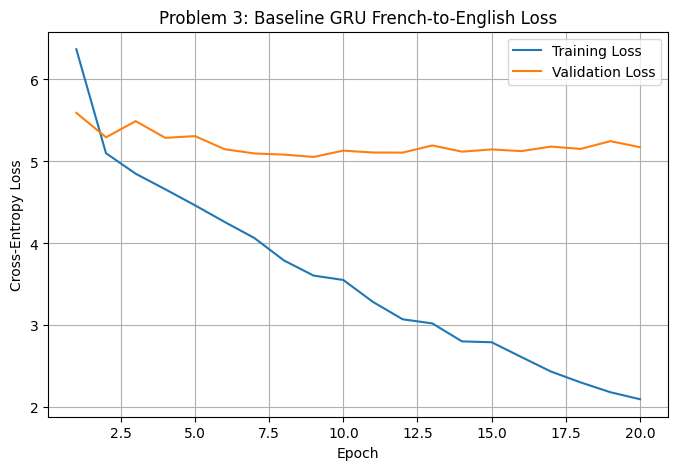

In [ ]:
# @title
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(p3_baseline_train_losses) + 1),
    p3_baseline_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(p3_baseline_val_losses) + 1),
    p3_baseline_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3: Baseline GRU French-to-English Loss")
plt.legend()
plt.grid(True)
plt.savefig("problem3_baseline_gru_fr_to_eng_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# @title
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[1]

        hidden_last = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(torch.cat((hidden_last, encoder_outputs), dim=2))
        )

        attention_scores = self.v(energy).squeeze(2)

        attention_scores = attention_scores.masked_fill(mask == 0, -1e10)

        attention_weights = torch.softmax(attention_scores, dim=1)

        return attention_weights


class AttentionEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        encoder_outputs, hidden = self.gru(embedded)

        return encoder_outputs, hidden


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            emb_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(emb_dim + hidden_dim * 2, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))

        attention_weights = self.attention(hidden, encoder_outputs, mask)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        )

        rnn_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(rnn_input, hidden)

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)

        prediction = self.fc_out(
            torch.cat((output, context, embedded), dim=1)
        )

        return prediction, hidden, attention_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return src != PAD_IDX

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]
        src_len = src.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        attentions = torch.zeros(batch_size, tgt_len, src_len).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        input_token = tgt[:, 0]

        mask = self.create_mask(src)

        for t in range(1, tgt_len):
            prediction, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            outputs[:, t, :] = prediction
            attentions[:, t, :] = attention_weights

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs, attentions

In [ ]:
# @title
attention = Attention(HIDDEN_DIM)

p3_attention_encoder = AttentionEncoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

p3_attention_decoder = AttentionDecoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention
)

p3_attention_model = Seq2SeqAttention(
    p3_attention_encoder,
    p3_attention_decoder,
    device
).to(device)

p3_attention_optimizer = torch.optim.Adam(p3_attention_model.parameters(), lr=0.001)

print("Problem 3 Attention GRU Parameters:", count_parameters(p3_attention_model))

Problem 3 Attention GRU Parameters: 5310593


In [ ]:
# @title
def train_one_epoch_attention(model, loader, optimizer, criterion, clip=1.0):
    model.train()

    epoch_loss = 0

    for src, tgt in tqdm(loader, desc="Training Attention", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output, _ = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]

        output = output[:, 1:, :].contiguous().view(-1, output_dim)
        tgt = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(output, tgt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_loss_attention(model, loader, criterion):
    model.eval()

    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in tqdm(loader, desc="Validation Attention", leave=False):
            src = src.to(device)
            tgt = tgt.to(device)

            output, _ = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].contiguous().view(-1, output_dim)
            tgt = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
# @title
EPOCHS_ATTENTION = 20

p3_attention_train_losses = []
p3_attention_val_losses = []

for epoch in range(EPOCHS_ATTENTION):
    train_loss = train_one_epoch_attention(
        p3_attention_model,
        train_loader,
        p3_attention_optimizer,
        criterion
    )

    val_loss = evaluate_loss_attention(
        p3_attention_model,
        val_loader,
        criterion
    )

    p3_attention_train_losses.append(train_loss)
    p3_attention_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02}/{EPOCHS_ATTENTION}")
    print(f"Attention Training Loss:   {train_loss:.4f}")
    print(f"Attention Validation Loss: {val_loss:.4f}")
    print()

Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/20
Attention Training Loss:   6.1571
Attention Validation Loss: 5.5597



Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20
Attention Training Loss:   0.1189
Attention Validation Loss: 5.4808



Training Attention:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Attention:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20
Attention Training Loss:   0.1041
Attention Validation Loss: 5.5524



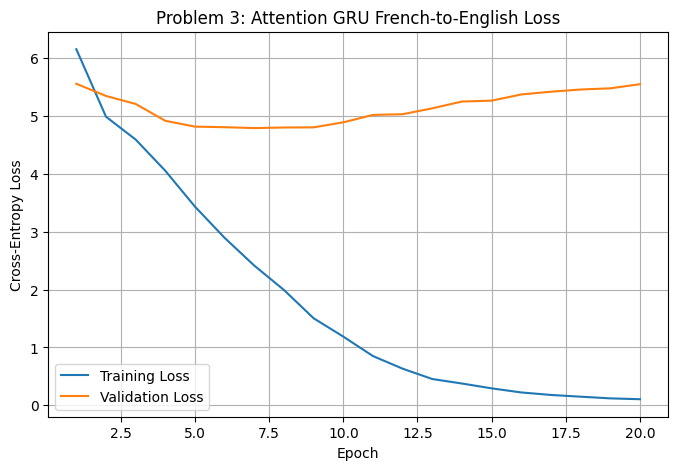

In [ ]:
# @title
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(p3_attention_train_losses) + 1),
    p3_attention_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(p3_attention_val_losses) + 1),
    p3_attention_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3: Attention GRU French-to-English Loss")
plt.legend()
plt.grid(True)
plt.savefig("problem3_attention_gru_fr_to_eng_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# @title
def translate_sentence_baseline(model, sentence, src_vocab, tgt_vocab, max_len=30):
    model.eval()

    sentence = normalize_text(sentence)

    src_ids = src_vocab.encode(sentence, add_sos=False, add_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

    input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(device)

    predicted_ids = []

    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden = model.decoder(input_token, hidden)

        top1 = prediction.argmax(1).item()

        if top1 == EOS_IDX:
            break

        predicted_ids.append(top1)
        input_token = torch.tensor([top1], dtype=torch.long).to(device)

    predicted_tokens = tgt_vocab.decode(predicted_ids)

    return predicted_tokens


def translate_sentence_attention(model, sentence, src_vocab, tgt_vocab, max_len=30):
    model.eval()

    sentence = normalize_text(sentence)

    src_tokens = sentence.split()
    src_ids = src_vocab.encode(sentence, add_sos=False, add_eos=True)

    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(device)

    predicted_ids = []

    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden, attention_weights = model.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

        top1 = prediction.argmax(1).item()

        if top1 == EOS_IDX:
            break

        predicted_ids.append(top1)
        input_token = torch.tensor([top1], dtype=torch.long).to(device)

    predicted_tokens = tgt_vocab.decode(predicted_ids)

    return predicted_tokens

In [ ]:
# @title
def evaluate_translation_metrics(model, pairs, src_vocab, tgt_vocab, model_type="baseline", max_len=30, limit=None):
    model.eval()

    smooth = SmoothingFunction().method1

    exact_matches = 0
    references = []
    hypotheses = []

    selected_pairs = pairs if limit is None else pairs[:limit]

    sample_rows = []

    for src_text, tgt_text in tqdm(selected_pairs, desc=f"Evaluating {model_type}"):
        if model_type == "baseline":
            pred_tokens = translate_sentence_baseline(
                model,
                src_text,
                src_vocab,
                tgt_vocab,
                max_len=max_len
            )
        else:
            pred_tokens = translate_sentence_attention(
                model,
                src_text,
                src_vocab,
                tgt_vocab,
                max_len=max_len
            )

        target_tokens = tgt_text.split()

        exact_match = pred_tokens == target_tokens

        if exact_match:
            exact_matches += 1

        references.append([target_tokens])
        hypotheses.append(pred_tokens)

        sent_bleu = sentence_bleu(
            [target_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        if len(sample_rows) < 5:
            sample_rows.append({
                "French Input": src_text,
                "Target English": tgt_text,
                "Predicted English": " ".join(pred_tokens),
                "Exact Match": exact_match,
                "Sentence BLEU-4": round(sent_bleu, 4)
            })

    sequence_accuracy = exact_matches / len(selected_pairs)

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return sequence_accuracy, bleu4, sample_rows

In [ ]:
# @title
p3_baseline_accuracy, p3_baseline_bleu4, p3_baseline_samples = evaluate_translation_metrics(
    p3_baseline_model,
    val_pairs,
    src_vocab,
    tgt_vocab,
    model_type="baseline",
    max_len=30,
    limit=None
)

p3_attention_accuracy, p3_attention_bleu4, p3_attention_samples = evaluate_translation_metrics(
    p3_attention_model,
    val_pairs,
    src_vocab,
    tgt_vocab,
    model_type="attention",
    max_len=30,
    limit=None
)

print("Problem 3 Results: French -> English")
print("------------------------------------")
print(f"Baseline Final Validation Loss: {p3_baseline_val_losses[-1]:.4f}")
print(f"Baseline Exact Sequence Accuracy: {p3_baseline_accuracy:.4f}")
print(f"Baseline BLEU-4 Score: {p3_baseline_bleu4:.4f}")
print()
print(f"Attention Final Validation Loss: {p3_attention_val_losses[-1]:.4f}")
print(f"Attention Exact Sequence Accuracy: {p3_attention_accuracy:.4f}")
print(f"Attention BLEU-4 Score: {p3_attention_bleu4:.4f}")

Evaluating baseline:   0%|          | 0/111 [00:00<?, ?it/s]

Evaluating attention:   0%|          | 0/111 [00:00<?, ?it/s]

Problem 3 Results: French -> English
------------------------------------
Baseline Final Validation Loss: 5.1740
Baseline Exact Sequence Accuracy: 0.0000
Baseline BLEU-4 Score: 0.0502

Attention Final Validation Loss: 5.5524
Attention Exact Sequence Accuracy: 0.0000
Attention BLEU-4 Score: 0.1334


In [ ]:
# @title
p3_baseline_sample_df = pd.DataFrame(p3_baseline_samples)
p3_attention_sample_df = pd.DataFrame(p3_attention_samples)

print("Baseline GRU samples:")
display(p3_baseline_sample_df)

print("Attention GRU samples:")
display(p3_attention_sample_df)

Baseline GRU samples:


,French Input,Target English,Predicted English,Exact Match,Sentence BLEU-4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,they built a cozy treehouse for the the,False,0.0366
1,elle pratique le yoga tous les matins,she practices yoga every morning,she practices the cello for the the,False,0.0699
2,j'aime marcher dans la neige,i enjoy walking in the snow,i cannot find my passport in the ocean,False,0.0650
3,elle adore porter des vestes modernes,she loves to wear modern jackets,she loves to wear long flowing,False,0.5081
4,le bus de la ville arrive précisément à cinq h...,the city bus arrives precisely at five o'clock,the chef prepared a special menu the,False,0.0286


Attention GRU samples:


,French Input,Target English,Predicted English,Exact Match,Sentence BLEU-4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,they go ice the beach,False,0.0428
1,elle pratique le yoga tous les matins,she practices yoga every morning,she practices the cello for three,False,0.0863
2,j'aime marcher dans la neige,i enjoy walking in the snow,i enjoy walking in the dense forest,False,0.6148
3,elle adore porter des vestes modernes,she loves to wear modern jackets,she loves to wear modern leather jackets,False,0.6435
4,le bus de la ville arrive précisément à cinq h...,the city bus arrives precisely at five o'clock,the regional train arrives at the branch,False,0.0377


In [ ]:
# @title
p3_baseline_sample_df.to_csv("problem3_baseline_fr_to_eng_samples.csv", index=False)
p3_attention_sample_df.to_csv("problem3_attention_fr_to_eng_samples.csv", index=False)

In [ ]:
# @title
problem3_comparison_df = pd.DataFrame({
    "Model": ["Baseline GRU French->English", "Attention GRU French->English"],
    "Final Validation Loss": [p3_baseline_val_losses[-1], p3_attention_val_losses[-1]],
    "Exact Sequence Accuracy": [p3_baseline_accuracy, p3_attention_accuracy],
    "Validation BLEU-4": [p3_baseline_bleu4, p3_attention_bleu4]
})

problem3_comparison_df

,Model,Final Validation Loss,Exact Sequence Accuracy,Validation BLEU-4
0,Baseline GRU French->English,5.173974,0.0,0.050221
1,Attention GRU French->English,5.552435,0.0,0.133365


In [ ]:
# @title
problem3_comparison_df.to_csv("problem3_fr_to_eng_comparison.csv", index=False)

In [ ]:
# @title
# Replace these with your actual Problem 1 and Problem 2 results
problem1_eng_to_fr_baseline_loss = 0.0000
problem1_eng_to_fr_baseline_accuracy = 0.0000
problem1_eng_to_fr_baseline_bleu4 = 0.0000

problem2_eng_to_fr_attention_loss = 0.0000
problem2_eng_to_fr_attention_accuracy = 0.0000
problem2_eng_to_fr_attention_bleu4 = 0.0000

direction_comparison_df = pd.DataFrame({
    "Direction and Model": [
        "English->French Baseline GRU",
        "English->French Attention GRU",
        "French->English Baseline GRU",
        "French->English Attention GRU"
    ],
    "Final Validation Loss": [
        problem1_eng_to_fr_baseline_loss,
        problem2_eng_to_fr_attention_loss,
        p3_baseline_val_losses[-1],
        p3_attention_val_losses[-1]
    ],
    "Exact Sequence Accuracy": [
        problem1_eng_to_fr_baseline_accuracy,
        problem2_eng_to_fr_attention_accuracy,
        p3_baseline_accuracy,
        p3_attention_accuracy
    ],
    "Validation BLEU-4": [
        problem1_eng_to_fr_baseline_bleu4,
        problem2_eng_to_fr_attention_bleu4,
        p3_baseline_bleu4,
        p3_attention_bleu4
    ]
})

direction_comparison_df

,Direction and Model,Final Validation Loss,Exact Sequence Accuracy,Validation BLEU-4
0,English->French Baseline GRU,0.000000,0.0,0.000000
1,English->French Attention GRU,0.000000,0.0,0.000000
2,French->English Baseline GRU,5.173974,0.0,0.050221
3,French->English Attention GRU,5.552435,0.0,0.133365


In [ ]:
# @title
direction_comparison_df.to_csv("problem3_direction_comparison.csv", index=False)